# OLS Baseline Model Workflow

This notebook implements the OLS baseline workflow for the Data Fitting project using the OASIS longitudinal dataset. It reuses the custom `ols_fit` implementation from Part 1 through the existing `OLSBaseline` class, preprocesses the data with `DataPipeline`, evaluates only on a held-out test set, and reports model diagnostics.

## 1. Imports

The notebook imports project modules without modifying them. The project root is added to `sys.path` so imports work when this notebook is executed from the `part2` directory.

In [10]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Resolve project paths robustly for notebook execution.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "part2" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from part2.data_pipeline import DataPipeline
from part2.model_comparison import OLSBaseline

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Reproducibility

A fixed seed is used for NumPy, the train/test split, and the OLS baseline wrapper.

In [11]:
SEED = 42
TEST_SIZE = 0.20

np.random.seed(SEED)

## 3. Load Dataset

The OASIS longitudinal dataset is loaded from the required relative path: `data/oasis_longitudinal.csv`.

In [12]:
DATA_PATH = Path("data") / "oasis_longitudinal.csv"

pipeline = DataPipeline()
df_raw = pipeline.load_dataset(str(DATA_PATH))

print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())
display(pd.DataFrame({"dtype": df_raw.dtypes, "missing": df_raw.isna().sum()}))

Dataset shape: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


,dtype,missing
Subject ID,object,0
MRI ID,object,0
Group,object,0
Visit,int64,0
MR Delay,int64,0
M/F,object,0
Hand,object,0
Age,int64,0
EDUC,int64,0
SES,float64,19


## 4. Remove ID Columns

`Subject ID` and `MRI ID` are high-cardinality identifiers. They are removed before modeling because they do not represent generalizable clinical predictors.

In [13]:
ID_COLUMNS = ["Subject ID", "MRI ID"]

df = df_raw.drop(columns=ID_COLUMNS).copy()
df = pipeline.remove_duplicates(df)

print(f"Shape after removing ID columns and duplicates: {df.shape}")
display(df.head())

Shape after removing ID columns and duplicates: (373, 13)


,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## 5. Handle Missing Values

Rows with missing target values are removed because the model cannot learn or evaluate without `MMSE`. Feature missingness is left for `DataPipeline`, which learns imputation statistics from the training set only.

In [14]:
TARGET = "MMSE"

rows_before = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
rows_after = len(df)

print(f"Rows removed for missing target ({TARGET}): {rows_before - rows_after}")
display(pd.DataFrame({"missing_after_target_filter": df.isna().sum()}))

Rows removed for missing target (MMSE): 2


,missing_after_target_filter
Group,0
Visit,0
MR Delay,0
M/F,0
Hand,0
Age,0
EDUC,0
SES,17
MMSE,0
CDR,0


## 6. Define Features and Target

`MMSE` is the response variable. All remaining columns are candidate predictors after removing the identifier columns.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
display(X.head())

Feature shape: (371, 12)
Target shape: (371,)


,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,R,87,14,2.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,R,88,14,2.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,R,75,12,NaN,0.5,1678,0.736,1.046
3,Demented,2,560,M,R,76,12,NaN,0.5,1738,0.713,1.010
4,Demented,3,1895,M,R,80,12,NaN,0.5,1698,0.701,1.034


## 7. Train/Test Split

The split occurs before fitting the preprocessing pipeline. This keeps the test set held out and prevents leakage from test-set statistics into training.

In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
)

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_test_raw:  {X_test_raw.shape}")
print(f"y_train:     {y_train.shape}")
print(f"y_test:      {y_test.shape}")

X_train_raw: (296, 12)
X_test_raw:  (75, 12)
y_train:     (296,)
y_test:      (75,)


## 8. Data Preprocessing

`DataPipeline.fit_transform` is applied to the training features, and `DataPipeline.transform` is applied to the held-out test features. The output is then converted to numeric NumPy arrays for the custom OLS implementation.

In [17]:
pipeline = DataPipeline()

# Fit preprocessing only on the training set.
X_train_processed = pipeline.fit_transform(X_train_raw, y_train)
X_test_processed = pipeline.transform(X_test_raw)

# Convert one-hot booleans and scaled numerics to a fully numeric matrix.
X_train_numeric = X_train_processed.apply(pd.to_numeric, errors="coerce")
X_test_numeric = X_test_processed.apply(pd.to_numeric, errors="coerce")

# Align columns explicitly and sanitize any remaining non-finite values.
feature_names = X_train_numeric.columns.tolist()
X_test_numeric = X_test_numeric.reindex(columns=feature_names)

train_fill_values = X_train_numeric.replace([np.inf, -np.inf], np.nan).median(numeric_only=True)
train_fill_values = train_fill_values.fillna(0.0)

X_train_numeric = X_train_numeric.replace([np.inf, -np.inf], np.nan).fillna(train_fill_values)
X_test_numeric = X_test_numeric.replace([np.inf, -np.inf], np.nan).fillna(train_fill_values)

X_train_array = X_train_numeric.to_numpy(dtype=float)
X_test_array = X_test_numeric.to_numpy(dtype=float)
y_train_array = y_train.to_numpy(dtype=float)
y_test_array = y_test.to_numpy(dtype=float)

print(f"Processed training matrix: {X_train_array.shape}")
print(f"Processed test matrix:     {X_test_array.shape}")
display(X_train_numeric.head())

Processed training matrix: (296, 15)
Processed test matrix:     (75, 15)


,Visit,MR Delay,Age,EDUC,SES,CDR,eTIV,nWBV,ASF,Group_Nondemented,Group_Demented,Group_Converted,M/F_M,M/F_F,Hand_R
192,-0.9756,-0.9502,-0.2132,-0.9184,1.3426,-0.7518,0.0991,0.2425,-0.2092,True,False,False,True,False,True
75,2.2692,2.9653,1.6278,-0.9184,1.3426,0.5495,-0.0511,-0.6352,-0.0686,False,True,False,True,False,True
84,-0.9756,-0.9502,-0.8707,0.8468,0.4631,-0.7518,0.8445,0.9607,-0.8903,True,False,False,False,True,True
359,-0.9756,-0.9502,-1.3967,-0.5653,-0.4165,-0.7518,0.0067,0.4287,-0.1204,True,False,False,False,True,True
16,0.1060,-0.0510,-1.0022,-0.9184,-0.4165,0.5495,-0.0800,1.6256,-0.0315,False,True,False,True,False,True


## 9. Sanity Checks

These checks verify that the custom OLS implementation receives finite numeric arrays with matching dimensions. This directly prevents the previous `ValueError: Input contains NaN` during test evaluation.

In [18]:
def summarize_array(name, values):
    values = np.asarray(values, dtype=float)
    return {
        "name": name,
        "shape": values.shape,
        "nan_count": int(np.isnan(values).sum()),
        "inf_count": int(np.isinf(values).sum()),
        "finite": bool(np.isfinite(values).all()),
    }

sanity_table = pd.DataFrame([
    summarize_array("X_train_array", X_train_array),
    summarize_array("X_test_array", X_test_array),
    summarize_array("y_train_array", y_train_array),
    summarize_array("y_test_array", y_test_array),
])

display(sanity_table)

assert X_train_array.shape[0] == y_train_array.shape[0]
assert X_test_array.shape[0] == y_test_array.shape[0]
assert X_train_array.shape[1] == X_test_array.shape[1]
assert np.isfinite(X_train_array).all()
assert np.isfinite(X_test_array).all()
assert np.isfinite(y_train_array).all()
assert np.isfinite(y_test_array).all()

,name,shape,nan_count,inf_count,finite
0,X_train_array,"(296, 15)",0,0,True
1,X_test_array,"(75, 15)",0,0,True
2,y_train_array,"(296,)",0,0,True
3,y_test_array,"(75,)",0,0,True


## 10. Train OLS Baseline

The baseline model is trained on the preprocessed training set. Internally, `OLSBaseline.fit` calls the Part 1 `ols_fit(X, y)` function.

In [19]:
ols_model = OLSBaseline(random_state=SEED)
ols_model.fit(X_train_array, y_train_array)

print("OLS baseline fitted successfully.")
print(f"Number of coefficients including intercept: {len(ols_model.beta_hat)}")
print(f"Estimated residual variance: {ols_model.sigma2_hat:.4f}")

OLS baseline fitted successfully.
Number of coefficients including intercept: 16
Estimated residual variance: 6.2432


## 11. Model Evaluation

Evaluation is performed strictly on the held-out test set. The reported metrics are MAE, RMSE, and test-set R-squared.

In [20]:
metrics = ols_model.evaluate(X_test_array, y_test_array)

metrics_table = pd.DataFrame([metrics], index=["OLS Baseline"])
display(metrics_table)

,MAE,RMSE,R2_test
OLS Baseline,1.7376,2.8904,0.4551


## 12. Coefficient Inference

Coefficient inference is computed with `coef_inference()` through `OLSBaseline.run_inference`. The table includes coefficient estimates, standard errors, t-statistics, p-values, and 95% confidence intervals.

In [25]:
inference_table = ols_model.run_inference(feature_names)

display(inference_table)

,feature,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
0,Intercept,9.7470,0.0701,139.0666,2.0270e-260,9.6090,9.8849
1,Visit,-0.4977,0.4060,-1.2259,2.2127e-01,-1.2968,0.3015
2,MR Delay,0.4642,0.4104,1.1310,2.5902e-01,-0.3437,1.2722
3,Age,0.4584,0.1851,2.4762,1.3871e-02,0.0940,0.8228
4,EDUC,0.1902,0.2226,0.8546,3.9349e-01,-0.2479,0.6284
5,SES,-0.3710,0.2261,-1.6408,1.0197e-01,-0.8161,0.0741
6,CDR,-2.1497,0.2790,-7.7043,2.2897e-13,-2.6989,-1.6004
7,eTIV,-0.0071,1.0161,-0.0070,9.9445e-01,-2.0073,1.9931
8,nWBV,0.8225,0.1979,4.1562,4.3043e-05,0.4329,1.2120
9,ASF,-0.0037,1.0031,-0.0037,9.9709e-01,-1.9783,1.9710


## 13. VIF Analysis

Variance Inflation Factor is computed on the preprocessed training matrix. Features with `VIF > 10` are flagged as having high multicollinearity.

In [22]:
vif_table = ols_model.compute_vif(X_train_array, feature_names)
vif_table = vif_table.sort_values("VIF", ascending=False, na_position="last").reset_index(drop=True)

display(vif_table)

high_vif_table = vif_table[vif_table["High Multicollinearity"]]
print(f"Number of features with VIF > 10: {len(high_vif_table)}")

,feature,VIF,High Multicollinearity
0,Group_Nondemented,inf,True
1,Group_Demented,inf,True
2,Group_Converted,inf,True
3,M/F_M,inf,True
4,M/F_F,inf,True
5,Hand_R,inf,True
6,eTIV,48.7859,True
7,ASF,47.5478,True
8,MR Delay,7.9603,False
9,Visit,7.7870,False


Number of features with VIF > 10: 8


## 14. Residual Diagnostic Plots

The four standard residual diagnostics are generated from the fitted training residuals: Residuals vs Fitted, Q-Q Plot, Scale-Location, and Cook's Distance.

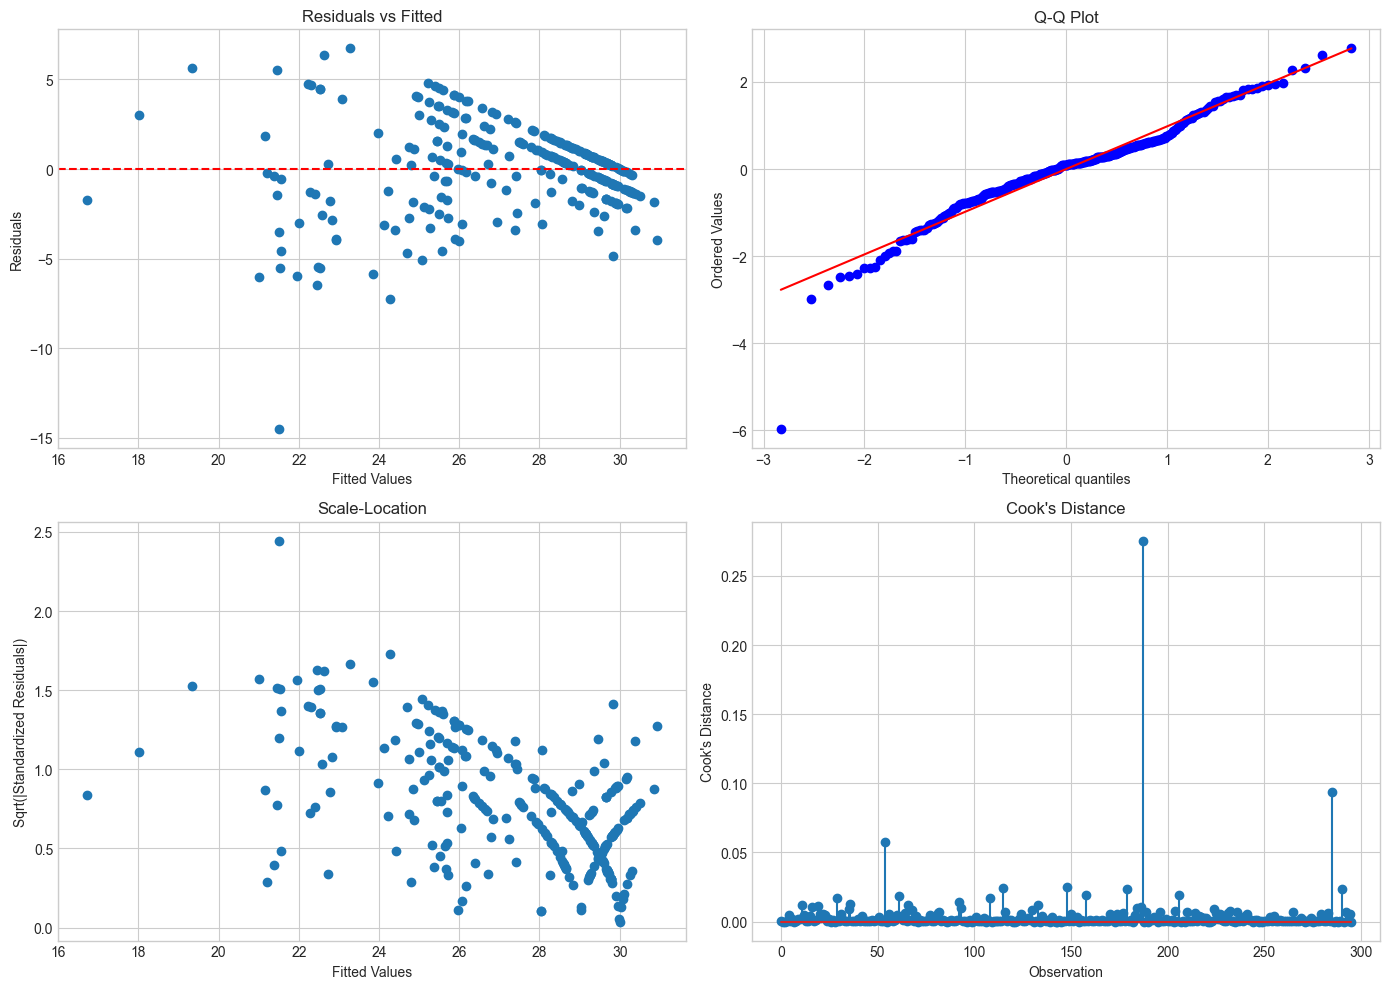

In [23]:
ols_model.diagnostic_plots()

## 15. Final Conclusion

This notebook completed the OLS baseline workflow end to end: data loading, identifier removal, missing-target filtering, leakage-safe train/test splitting, `DataPipeline` preprocessing, numeric array conversion, finite-value sanity checks, OLS training with the Part 1 implementation, held-out test evaluation, coefficient inference, VIF analysis, and residual diagnostics.